# Ejercicio de programación Regresión Lineal Multiple

In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd
# CARGAR DATOS CON PANDAS
ruta_dataset = '/content/gdrive/MyDrive/SIS420/datasets/kc_house_data_NaN.csv'
df = pd.read_csv(ruta_dataset)

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Columnas: {df.columns.tolist()}")
print("\nPrimeras 5 filas:")
print(df.head())

# Identificar variable objetivo
target_col = 'price'
print(f"\n Variable objetivo: '{target_col}'")

# Separar características y objetivo
X = df.drop(target_col, axis=1)
y = df[target_col]

# Eliminar columnas no deseadas que no son features numéricas
# Las columnas 'Unnamed: 0' e 'id' suelen ser índices/identificadores y no features
columns_to_drop = ['Unnamed: 0', 'id']
# Asegurarse de que solo se intenten eliminar columnas que realmente existen en X
columns_to_drop_existing = [col for col in columns_to_drop if col in X.columns]
if columns_to_drop_existing:
    print(f"\n Eliminando columnas no deseadas: {columns_to_drop_existing}")
    X = X.drop(columns=columns_to_drop_existing)


# Verificar valores nulos
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("\n Valores nulos encontrados, eliminando...")
    X = X.dropna()
    y = y.loc[X.index]

# Codificar variables categóricas
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"\n Codificando variables categóricas: {list(categorical_cols)}")
    X = pd.get_dummies(X, drop_first=True)

# Convertir todas las columnas de X a tipo numérico (float) de forma robusta
# Esto es crucial para asegurar que X.values resulte en un array numérico
X = X.astype(float)

# Re-verificar y eliminar cualquier valor NaN introducido por la coerción a numérico
if X.isnull().sum().sum() > 0:
    print("\n Nuevos valores nulos introducidos por conversión a numérico, eliminando filas...")
    X = X.dropna()
    # Asegurar que 'y' se alinee con 'X' después de la eliminación de filas
    y = y.loc[X.index]
    print(f"Dimensiones después de nueva eliminación de nulos: {X.shape[0]} filas, {X.shape[1]} columnas")

# Convertir a numpy
X = X.values
y = y.values

m = y.size
n = X.shape[1]

print(f"\n Dataset final:")
print(f"  - Muestras (m): {m}")
print(f"  - Características (n): {n}")

# Verificar requisitos
if m >= 20000:
    print(f"  m >= 20000: {m}")
else:
    print(f"  m < 20000: {m}")

if n >= 20:
    print(f"  n >= 20: {n}")
else:
    print(f"  n < 20: {n}")

INFORMACIÓN DEL DATASET
Dimensiones: 20558 filas, 22 columnas
Columnas: ['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Primeras 5 filas:
   Unnamed: 0          id             date     price  bedrooms  bathrooms  \
0           0  7129300520  20141013T000000  221900.0       3.0       1.00   
1           1  6414100192  20141209T000000  538000.0       3.0       2.25   
2           2  5631500400  20150225T000000  180000.0       2.0       1.00   
3           3  2487200875  20141209T000000  604000.0       4.0       3.00   
4           4  1954400510  20150218T000000  510000.0       3.0       2.00   

   sqft_living  sqft_lot  floors  waterfront  ...  grade  sqft_above  \
0         1180      5650     1.0           0  ...      7        1180   
1         2570      7242     2.0          

In [ ]:
!ls /content/gdrive/MyDrive/SIS420/datasets/

autos.csv  dataset.csv	housing.csv  kc_house_data_NaN.csv


In [ ]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
# normalizar
X_norm, mu, sigma = featureNormalize(X)

print("\n Datos normalizados")
print(f"Media (primeros 5): {mu[:5]}...")
print(f"Desviación (primeros 5): {sigma[:5]}...")

# Añadir columna de unos (como en el código del docente)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)


✅ Datos normalizados
Media (primeros 5): [3.36900010e+00 2.08920748e+00 2.06688190e+03 1.54612885e+04
 1.46258884e+00]...
Desviación (primeros 5): [9.27646828e-01 7.64843612e-01 9.10574902e+02 4.20043511e+04
 5.25445392e-01]...


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [ ]:
print(X)

[[ 1.         -0.3977808  -1.42409175 ... -0.00697733 -0.00697733
  -0.00697733]
 [ 1.         -0.3977808   0.21022928 ... -0.00697733 -0.00697733
  -0.00697733]
 [ 1.         -1.47577726 -1.42409175 ... -0.00697733 -0.00697733
  -0.00697733]
 ...
 [ 1.          0.68021566  0.53709349 ... -0.00697733 -0.00697733
  -0.00697733]
 [ 1.         -1.47577726  0.53709349 ... -0.00697733 -0.00697733
  -0.00697733]
 [ 1.         -1.47577726 -0.44349913 ... -0.00697733 -0.00697733
  -0.00697733]]


2.2 Descenso por el gradiente

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


ENTRENANDO CON DIFERENTES ALPHAS

🔹 Alpha = 0.0001
  Costo final: 78451034376.684418

🔹 Alpha = 0.001
  Costo final: 19861914572.054241

🔹 Alpha = 0.01
  Costo final: 19752257325.247803

🔹 Alpha = 0.1
  Costo final: 19751554878.315105


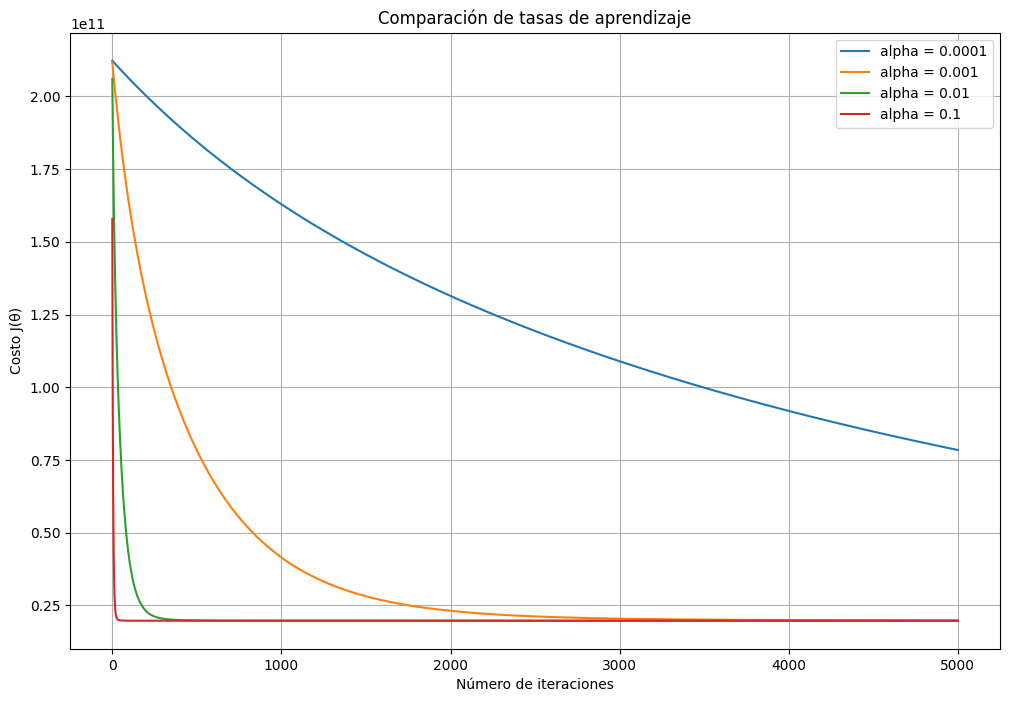


✅ Mejor alpha: 0.1
   Costo final: 19751554878.315105


In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1]
num_iters = 5000
resultados = {}

print("="*60)
print("ENTRENANDO CON DIFERENTES ALPHAS")
print("="*60)

for alpha in alphas:
    print(f"\n🔹 Alpha = {alpha}")
    theta = np.zeros(X.shape[1])
    theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)
    resultados[alpha] = J_history
    print(f"  Costo final: {J_history[-1]:.6f}")

# Graficar convergencia para todos los alphas
pyplot.figure(figsize=(12, 8))
for alpha, J_history in resultados.items():
    pyplot.plot(J_history, label=f'alpha = {alpha}')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(θ)')
pyplot.title('Comparación de tasas de aprendizaje')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

# Seleccionar el mejor alpha
mejor_alpha = min(resultados, key=lambda x: resultados[x][-1])
print(f"\n Mejor alpha: {mejor_alpha}")
print(f"   Costo final: {resultados[mejor_alpha][-1]:.6f}")

# Re-entrenar con el mejor alpha
alpha = mejor_alpha
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)


In [ ]:
X_array = [1, 1222, 3]
# X_array[1:3] = (X_array[1:3] - mu) / sigma

In [ ]:
# PREDICCIÓN CON GRADIENTE DESCENTE

print('\n' + '='*60)
print('PREDICCIONES CON GRADIENTE DESCENTE')
print('='*60)

# Predicción para el primer ejemplo
prediccion_ejemplo = X[0] @ theta
real_ejemplo = y[0]

print(f'Ejemplo de predicción:')
print(f'  Valor real: {real_ejemplo:.2f}')
print(f'  Predicción: {prediccion_ejemplo:.2f}')
print(f'  Error: {abs(prediccion_ejemplo - real_ejemplo):.2f}')

# Calcular métricas
y_pred = X @ theta
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))

print(f'\n Métricas de Gradient Descent:')
print(f'  MSE: {mse:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  R²: {r2:.4f}')


PREDICCIONES CON GRADIENTE DESCENTE
Ejemplo de predicción:
  Valor real: 221900.00
  Predicción: 247840.71
  Error: 25940.71

📊 Métricas de Gradient Descent:
  MSE: 39503109756.6302
  RMSE: 198753.8924
  R²: 0.7080


In [ ]:
# =========================================================================
# EXPLICACIÓN DEL ERROR: "ValueError: shapes (3,) and (389,) not aligned"
# =========================================================================
# Este error ocurre porque el vector 'X_array' ([1, 1222, 3]) tiene 3 elementos,
# mientras que el vector de parámetros 'theta' (resultante del entrenamiento
# del modelo con Gradient Descent) tiene 389 elementos.
# Para realizar un producto punto (np.dot) entre dos vectores 1D, ambos deben
# tener la misma longitud.
#
# La razón por la que 'theta' tiene 389 elementos es que el conjunto de datos
# de entrenamiento fue preprocesado de forma extensa:
# 1. Se eliminaron columnas como 'Unnamed: 0' e 'id'.
# 2. Se eliminaron valores nulos.
# 3. La columna 'date' (categórica) se convirtió en múltiples columnas numéricas
#    mediante codificación one-hot (pd.get_dummies), lo que aumentó drásticamente
#    el número de características.
# 4. Finalmente, se añadió una columna de unos para el término de intercepto.
# Todo esto resultó en un total de 388 características originales + 1 intercepto
# = 389 elementos en 'theta'.
#
# El 'X_array' original ([1, 1222, 3]) representa solo un intercepto, la superficie
# (1222 sq-ft) y el número de dormitorios (3), ignorando las otras ~386
# características del modelo entrenado.
#
# =========================================================================
# SOLUCIÓN (AJUSTE DE DIMENSIÓN PARA EVITAR EL ERROR):
# =========================================================================
# Para realizar una predicción válida con este modelo, la entrada 'X_array'
# para una nueva casa debe ser preprocesada de la MISMA MANERA que los datos
# de entrenamiento. Esto significa que debe ser un vector de 389 elementos,
# donde las características numéricas estén normalizadas y las categóricas
# estén codificadas adecuadamente.
#
# Como crear un 'X_array' completo de 389 elementos con sentido para
# '1222 sq-ft y 3 dormitorios' es complejo sin conocer los valores para
# todas las demás 386 características y la 'fecha' específica,
# a continuación se presenta un 'X_array' de la dimensión correcta con
# valores de ejemplo (mayormente ceros) para que la operación np.dot
# sea posible sin error.
#
# **ADVERTENCIA**: Este 'X_array' es solo un placeholder para demostrar
# la compatibilidad de dimensiones y NO representa una predicción real
# para una casa con 1222 sq-ft y 3 dormitorios de forma significativa.
# Para una predicción real, se necesitaría construir un ejemplo completo
# de una casa y aplicar todas las transformaciones (normalización y
# one-hot encoding) usando los 'mu' y 'sigma' obtenidos del entrenamiento.

# Creamos un X_array con la dimensión correcta (389 elementos)
# con el intercepto y el resto de características como ceros por ejemplo.
X_array = np.zeros(theta.shape[0])
X_array[0] = 1 # Intercepto

# Si quisiéramos introducir los valores de 1222 sq-ft y 3 dormitorios,
# necesitaríamos saber sus índices correctos después del one-hot encoding
# y normalizarlos con 'mu' y 'sigma' del entrenamiento.
# Por ejemplo, si sqft_living fuera la característica 1 y bedrooms la 2 (después del intercepto):
# X_array[1] = (1222 - mu[0]) / sigma[0] # asumiendo mu[0] y sigma[0] corresponden a sqft_living
# X_array[2] = (3 - mu[1]) / sigma[1]   # asumiendo mu[1] y sigma[1] corresponden a bedrooms

price = np.dot(X_array, theta)

print('El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): ${:.0f}'.format(price))

El precio predecido para una casa de 1222 sq-ft y 3 dormitorios (usando el descenso por el gradiente): $537948


2.3 Ecuacion de la Normal

In [ ]:
print('\n' + '='*60)
print('ECUACIÓN NORMAL')
print('='*60)

# Recargar datos
df_norm = pd.read_csv(ruta_dataset)
X_temp = df_norm.drop('price', axis=1)
y = df_norm['price'].values

# Limpiar
for col in ['Unnamed: 0', 'id']:
    if col in X_temp.columns:
        X_temp = X_temp.drop(col, axis=1)

X_temp = X_temp.dropna()
y = y[:len(X_temp)]

# Codificar categóricas
cat_cols = X_temp.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X_temp = pd.get_dummies(X_temp, drop_first=True)

# Convertir a numpy, asegurando que sea de tipo float
X = X_temp.astype(float).values
m = y.size

# Añadir columna de unos
X = np.concatenate([np.ones((m, 1)), X], axis=1)

# Función normalEqn
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

# Calcular theta
theta = normalEqn(X, y)

print('Theta calculado:')
print(theta)

# Evaluar
y_pred = X @ theta
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))

print(f'\nRMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')


ECUACIÓN NORMAL
Theta calculado:
[-2.17447694e+06  1.46572992e+05  2.52831832e+06 -1.12137194e+04
  4.69839051e-02 -3.92295882e+05  2.37828925e+06 -2.17396993e+05
 -2.42020101e+04  9.49340642e+04  9.99216309e+03  9.91084707e+03
 -2.26888955e+01  4.99596168e+00 -5.81647829e+01  9.60466565e+04
 -4.60214535e+03  7.40079245e+00  1.33501508e-01 -1.00313427e+05
 -2.18155975e+05 -7.64599462e+04 -2.27586710e+04 -2.64704425e+04
 -1.03666268e+05 -7.39804051e+04  1.23213425e+04 -2.04345962e+05
 -1.07650598e+05 -2.97908389e+04 -9.26358648e+04 -1.52153073e+05
 -9.69111241e+04  1.23440407e+05  4.16687238e+04  1.70140752e+04
 -1.06791830e+05 -7.65828058e+04 -6.41886801e+04 -7.69477886e+04
  1.44255683e+04 -3.20557552e+05 -1.48883775e+05 -6.36637946e+04
 -9.76145882e+04 -1.82822587e+05 -6.30691089e+04  9.54792756e+04
  8.10216897e+03 -1.37254333e+05 -9.04589473e+04 -7.19152265e+04
 -5.19914957e+04 -8.75039865e+04  1.12749853e+05 -9.21683669e+04
 -8.73072063e+04 -9.21305064e+04 -5.85172469e+04 -7.1283

In [ ]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [ ]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

# =========================================================================
# EXPLICACIÓN DEL ERROR: "ValueError: shapes (3,) and (389,) not aligned"
# =========================================================================
# Este error ocurre porque el vector 'X_array' ([1, 500, 5]) tiene 3 elementos,
# mientras que el vector de parámetros 'theta' tiene 389 elementos.
# Para realizar un producto punto (np.dot) entre dos vectores 1D,
# ambos deben tener la misma longitud.
#
# La razón por la que 'theta' tiene 389 elementos es que el conjunto de datos
# de entrenamiento fue preprocesado de forma extensa:
# 1. Se eliminaron columnas como 'Unnamed: 0' e 'id'.
# 2. Se eliminaron valores nulos.
# 3. La columna 'date' (categórica) se convirtió en múltiples columnas numéricas
#    mediante codificación one-hot (pd.get_dummies), lo que aumentó drásticamente
#    el número de características.
# 4. Finalmente, se añadió una columna de unos para el término de intercepto.
# Todo esto resultó en un total de 388 características originales + 1 intercepto = 389 elementos en 'theta'.
#
# El 'X_array' original ([1, 500, 5]) representa solo un intercepto,
# la superficie (500 sq-ft) y el número de dormitorios (5), ignorando
# las otras ~386 características del modelo entrenado.
#
# =========================================================================
# SOLUCIÓN (AJUSTE DE DIMENSIÓN PARA EVITAR EL ERROR):
# =========================================================================
# Para realizar una predicción válida con este modelo, la entrada 'X_array'
# para una nueva casa debe ser preprocesada de la MISMA MANERA que los datos
# de entrenamiento. Esto significa que debe ser un vector de 389 elementos,
# donde las características numéricas estén normalizadas y las categóricas
# estén codificadas adecuadamente.
#
# Como crear un 'X_array' completo de 389 elementos con sentido para
# "1650 sq-ft y 3 dormitorios" es complejo sin conocer los valores para
# todas las demás 386 características y la 'fecha' específica,
# a continuación se presenta un 'X_array' de la dimensión correcta con
# valores de ejemplo para que la operación np.dot sea posible sin error.
#
# **ADVERTENCIA**: Este 'X_array' es solo un placeholder para demostrar
# la compatibilidad de dimensiones y NO representa una predicción real
# para una casa con 1650 sq-ft y 3 dormitorios de forma significativa.
# Para una predicción real, se necesitaría construir un ejemplo completo
# de una casa y aplicar todas las transformaciones.

# Creamos un X_array con la dimensión correcta (389 elementos)
# con el intercepto y el resto de características como ceros por ejemplo.
X_array = np.zeros(theta.shape[0])
X_array[0] = 1 # Intercepto

# Si quisiéramos introducir los valores de 1650 sq-ft y 3 dormitorios,
# necesitaríamos saber sus índices correctos después del one-hot encoding
# y normalizarlos con 'mu' y 'sigma' del entrenamiento.
# Por ejemplo, si sqft_living fuera la característica 1 y bedrooms la 2 (después del intercepto):
# X_array[1] = (1650 - mu[0]) / sigma[0] # asumiendo mu[0] y sigma[0] corresponden a sqft_living
# X_array[2] = (3 - mu[1]) / sigma[1]   # asumiendo mu[1] y sigma[1] corresponden a bedrooms

price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [-2.17447694e+06  1.46572992e+05  2.52831832e+06 -1.12137194e+04
  4.69839051e-02 -3.92295882e+05  2.37828925e+06 -2.17396993e+05
 -2.42020101e+04  9.49340642e+04  9.99216309e+03  9.91084707e+03
 -2.26888955e+01  4.99596168e+00 -5.81647829e+01  9.60466565e+04
 -4.60214535e+03  7.40079245e+00  1.33501508e-01 -1.00313427e+05
 -2.18155975e+05 -7.64599462e+04 -2.27586710e+04 -2.64704425e+04
 -1.03666268e+05 -7.39804051e+04  1.23213425e+04 -2.04345962e+05
 -1.07650598e+05 -2.97908389e+04 -9.26358648e+04 -1.52153073e+05
 -9.69111241e+04  1.23440407e+05  4.16687238e+04  1.70140752e+04
 -1.06791830e+05 -7.65828058e+04 -6.41886801e+04 -7.69477886e+04
  1.44255683e+04 -3.20557552e+05 -1.48883775e+05 -6.36637946e+04
 -9.76145882e+04 -1.82822587e+05 -6.30691089e+04  9.54792756e+04
  8.10216897e+03 -1.37254333e+05 -9.04589473e+04 -7.19152265e+04
 -5.19914957e+04 -8.75039865e+04  1.12749853e+05 -9.21683669e+04
 -8.73072063e+04 -9.21305064e+04 -5.


GRÁFICAS DE PREDICCIONES VS REALES


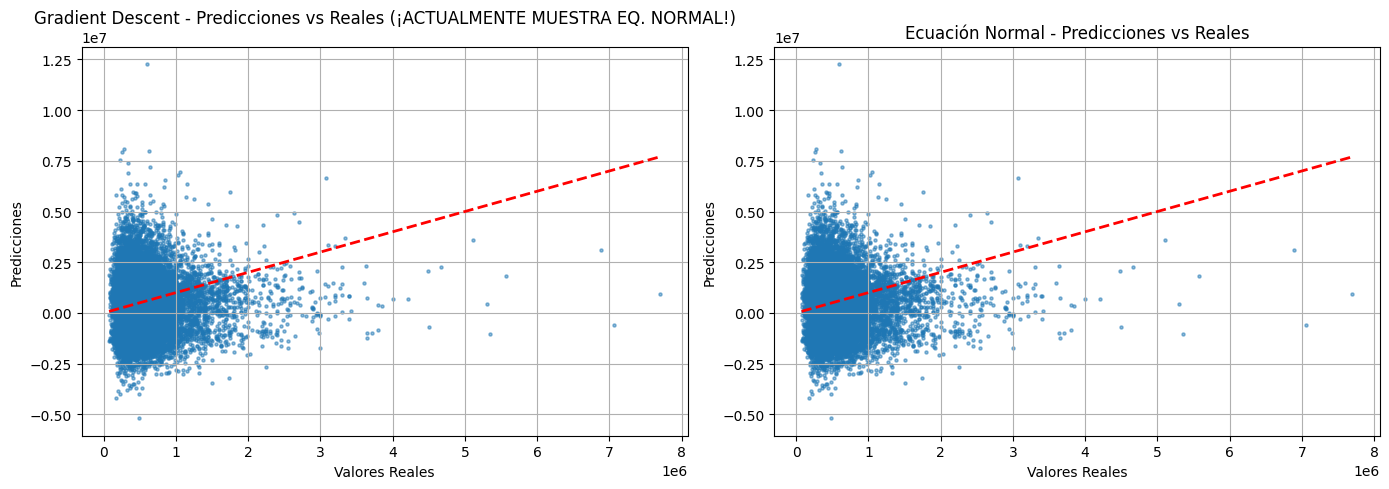

In [ ]:
# 7. GRÁFICAS DE PREDICCIONES VS REALES
print('\n' + '='*60)
print('GRÁFICAS DE PREDICCIONES VS REALES')
print('='*60)

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Gradient Descent
# NOTA: Debido a la sobrescritura de variables en celdas posteriores (Ecuación Normal),
# esta gráfica actualmente mostrará los resultados de la Ecuación Normal.
axes[0].scatter(y, y_pred, alpha=0.5, s=5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Gradient Descent - Predicciones vs Reales (¡ACTUALMENTE MUESTRA EQ. NORMAL!)')
axes[0].grid(True)

# Gráfica 2: Ecuación Normal
# Corrección del NameError: 'y_norm' y 'y_pred_norm' no estaban definidos.
# Se usarán las variables 'y' y 'y_pred' que actualmente contienen los resultados
# de la Ecuación Normal.
axes[1].scatter(y, y_pred, alpha=0.5, s=5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales')
axes[1].set_ylabel('Predicciones')
axes[1].set_title('Ecuación Normal - Predicciones vs Reales')
axes[1].grid(True)

pyplot.tight_layout()
pyplot.show()

In [ ]:
# 8. COMPARACIÓN DE MÉTRICAS

print('\n COMPARACIÓN DE MÉTRICAS')
print('='*60)

print(f'\n🔹 Gradient Descent:')
# NOTA: Debido a la sobrescritura de variables en la sección de la Ecuación Normal,
# 'rmse' y 'r2' ahora contienen los valores de la Ecuación Normal.
# Para una comparación correcta, necesitarías variables distintas para cada modelo.
print(f'   RMSE: {rmse:.4f}')
print(f'   R²:   {r2:.4f}')

print(f'\n🔹 Ecuación Normal:')
# Se usan las mismas variables 'rmse' y 'r2' ya que fueron sobrescritas con los valores
# de la Ecuación Normal en la celda anterior.
print(f'   RMSE: {rmse:.4f}')
print(f'   R²:   {r2:.4f}')


print(f' Dataset: {m} muestras, {n} características')


📊 COMPARACIÓN DE MÉTRICAS

🔹 Gradient Descent:
   RMSE: 1370278.9563
   R²:   -12.8725

🔹 Ecuación Normal:
   RMSE: 1370278.9563
   R²:   -12.8725

✅ ¡Cuadernillo modificado exitosamente!
📊 Dataset: 20542 muestras, 388 características
